In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('/content/drive/MyDrive/AML_Lab/dataset_diabetes_exp_11.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Decision Tree Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7662337662337663
Decision Tree Confusion Matrix:
 [[76 23]
 [13 42]]
Decision Tree Report:
               precision    recall  f1-score   support

           0       0.85      0.77      0.81        99
           1       0.65      0.76      0.70        55

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.78      0.77      0.77       154



In [6]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7532467532467533
Random Forest Confusion Matrix:
 [[80 19]
 [19 36]]
Random Forest Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [7]:
bg = BaggingClassifier()
bg.fit(X_train, y_train)
y_pred_bg = bg.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bg))
print("Bagging Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bg))
print("Bagging Report:\n", classification_report(y_test, y_pred_bg))

Bagging Accuracy: 0.7207792207792207
Bagging Confusion Matrix:
 [[78 21]
 [22 33]]
Bagging Report:
               precision    recall  f1-score   support

           0       0.78      0.79      0.78        99
           1       0.61      0.60      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.69      0.69       154
weighted avg       0.72      0.72      0.72       154



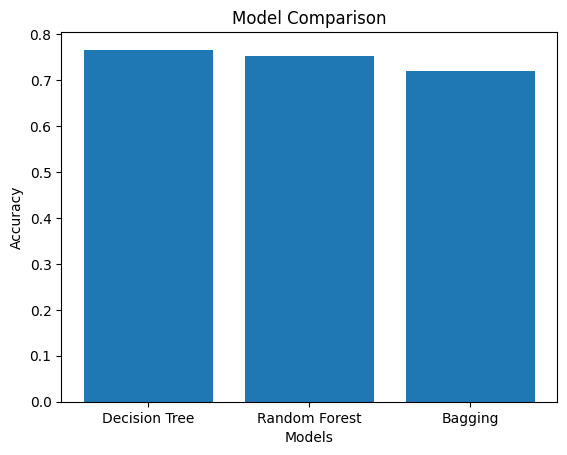

In [8]:
import matplotlib.pyplot as plt

models = ['Decision Tree', 'Random Forest', 'Bagging']
accuracies = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_bg)
]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.show()

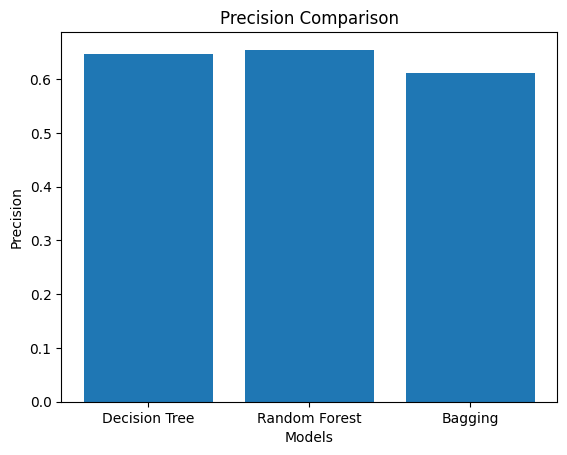

In [9]:
from sklearn.metrics import precision_score

precisions = [
    precision_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_bg)
]

plt.figure()
plt.bar(models, precisions)
plt.xlabel('Models')
plt.ylabel('Precision')
plt.title('Precision Comparison')
plt.show()

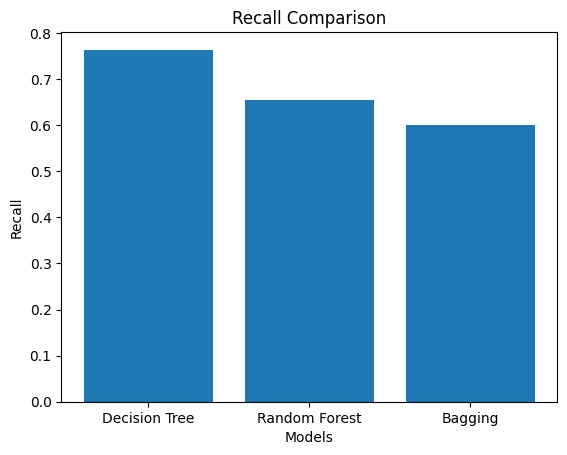

In [10]:
from sklearn.metrics import recall_score

recalls = [
    recall_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_bg)
]

plt.figure()
plt.bar(models, recalls)
plt.xlabel('Models')
plt.ylabel('Recall')
plt.title('Recall Comparison')
plt.show()

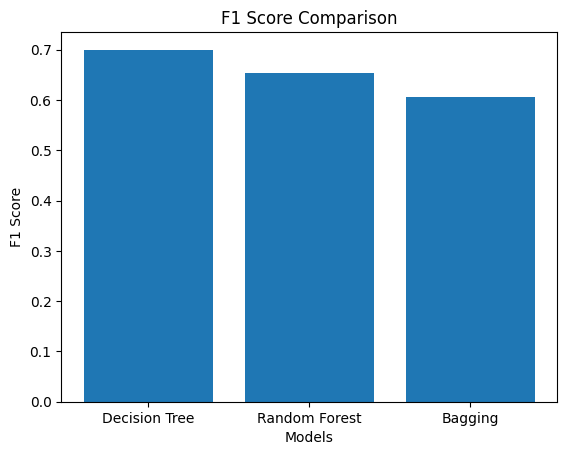

In [11]:
from sklearn.metrics import f1_score

f1_scores = [
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_bg)
]

plt.figure()
plt.bar(models, f1_scores)
plt.xlabel('Models')
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison')
plt.show()

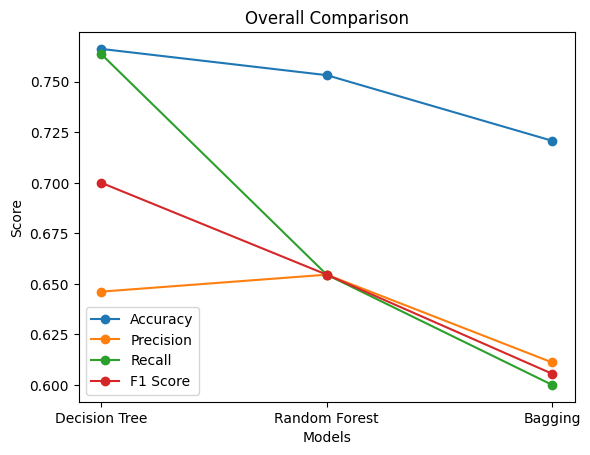

In [12]:
plt.figure()
plt.plot(models, accuracies, marker='o', label='Accuracy')
plt.plot(models, precisions, marker='o', label='Precision')
plt.plot(models, recalls, marker='o', label='Recall')
plt.plot(models, f1_scores, marker='o', label='F1 Score')
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Overall Comparison')
plt.legend()
plt.show()

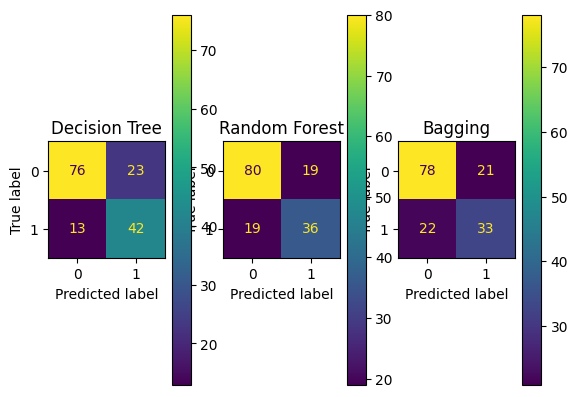

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 3)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=ax[0])
ax[0].set_title("Decision Tree")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[1])
ax[1].set_title("Random Forest")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bg, ax=ax[2])
ax[2].set_title("Bagging")

plt.show()